# Kidney Donor Eligibility Analysis

## Overview
This analysis examines trends in kidney donor eligibility based on health criteria using NHIS data (2015-2024).

### Donor Categories:
1. **Ideal Donors**: No Diabetes, No Hypertension, No Prediabetes, No Obesity (BMI < 30)
2. **Expanded Donors**: Same as ideal, but BMI threshold relaxed to < 35
3. **Marginal/Potential Donors**: No Diabetes + 7 combinations of HTN, Prediabetes, Obesity (BMI 30-35)

### Key Questions:
- What is the trend/projection of ideal donors over 10-20 years?
- How many additional donors if we expand BMI threshold to 35?
- How many people fall into each marginal donor category?

In [1]:
# Setup: Import libraries and load NHIS data
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_venn import venn3

# Add project root to path
current_dir = os.getcwd()
project_root = None
if os.path.exists(os.path.join(current_dir, "data_loader.py")):
    project_root = current_dir
elif os.path.exists(os.path.join(current_dir, "..", "data_loader.py")):
    project_root = os.path.abspath(os.path.join(current_dir, ".."))
if project_root and project_root not in sys.path:
    sys.path.append(project_root)

from data_loader import load_all_data, preprocess_data
from analysis import calculate_weighted_prevalence, fit_linear_trend, project_trend
from config import US_ADULT_POPULATION_2025

# Load and preprocess all NHIS data
print("Loading NHIS data (2015-2024)...")
dataframes = preprocess_data(load_all_data())
years = sorted(dataframes.keys())
print(f"\nYears available: {years}")

Loading NHIS data (2015-2024)...
Loaded data for 2015: 33672 rows
Loaded data for 2016: 33028 rows
Loaded data for 2017: 26742 rows
Loaded data for 2018: 25417 rows
Loaded data for 2019: 31997 rows
Loaded data for 2020: 31568 rows
Loaded data for 2021: 29482 rows
Loaded data for 2022: 27651 rows
Loaded data for 2023: 29522 rows
Loaded data for 2024: 32629 rows
Starting data preprocessing...
✓ Filtered to adults
✓ Filled missing health values
✓ Cleaned invalid values
✓ Calculated BMI
Year 2015: 27131 complete records (removed 6541 incomplete)
Year 2016: 26822 complete records (removed 6206 incomplete)
Year 2017: 21745 complete records (removed 4997 incomplete)
Year 2018: 20443 complete records (removed 4974 incomplete)
Year 2019: 28354 complete records (removed 3643 incomplete)
Year 2020: 28087 complete records (removed 3481 incomplete)
Year 2021: 25917 complete records (removed 3565 incomplete)
Year 2022: 24427 complete records (removed 3224 incomplete)
Year 2023: 26117 complete record

In [ ]:
## Section 1: Ideal vs Expanded Donor Eligibility

**Definitions:**
- **Ideal Donors**: No Diabetes + No Prediabetes + No Hypertension + BMI < 30
- **Expanded Donors**: No Diabetes + No Prediabetes + No Hypertension + BMI < 35

Calculate yearly prevalence and weighted population counts for both categories.

In [2]:
# Calculate Ideal vs Expanded Donor Eligibility by Year
def compute_eligibility(df, bmi_max=30):
    """
    Compute donor eligibility mask.
    Eligible = No Diabetes + No Prediabetes + No Hypertension + BMI < bmi_max
    """
    return (
        (df["diabetes"] != 1) &
        (df["prediabetes"] != 1) &
        (df["hypertension"] != 1) &
        (df["BMI"] < bmi_max)
    )

rows = []
for year in years:
    df = dataframes[year]
    
    # Ideal: BMI < 30
    ideal_mask = compute_eligibility(df, bmi_max=30)
    ideal_pct = calculate_weighted_prevalence(df, ideal_mask)
    ideal_n = df.loc[ideal_mask, "survey_weight"].sum()
    
    # Expanded: BMI < 35
    expanded_mask = compute_eligibility(df, bmi_max=35)
    expanded_pct = calculate_weighted_prevalence(df, expanded_mask)
    expanded_n = df.loc[expanded_mask, "survey_weight"].sum()
    
    rows.append({
        "Year": int(year),
        "Ideal % (BMI<30)": round(ideal_pct, 2),
        "Ideal N (millions)": round(ideal_n / 1_000_000, 2),
        "Expanded % (BMI<35)": round(expanded_pct, 2),
        "Expanded N (millions)": round(expanded_n / 1_000_000, 2),
        "Additional % (BMI 30-35)": round(expanded_pct - ideal_pct, 2),
        "Additional N (millions)": round((expanded_n - ideal_n) / 1_000_000, 2),
    })

eligibility_df = pd.DataFrame(rows).sort_values("Year")
print("Donor Eligibility by Year:")
eligibility_df

Donor Eligibility by Year:


,Year,Ideal % (BMI<30),Ideal N (millions),Expanded % (BMI<35),Expanded N (millions),Additional % (BMI 30-35),Additional N (millions)
0,2015,60.73,120.20,72.90,144.31,12.18,24.10
1,2016,59.63,120.06,71.64,144.24,12.01,24.18
2,2017,59.13,120.20,71.00,144.32,11.87,24.13
3,2018,58.88,119.51,71.31,144.74,12.43,25.23
4,2019,53.51,118.04,65.32,144.11,11.81,26.06
5,2020,53.08,117.49,64.85,143.53,11.77,26.05
6,2021,52.49,116.32,64.63,143.21,12.14,26.90
7,2022,52.28,116.79,64.03,143.04,11.75,26.26
8,2023,51.47,116.89,63.47,144.14,12.00,27.24
9,2024,51.13,116.53,62.72,142.93,11.58,26.40


In [ ]:
## Section 2: Trend Analysis & 10-20 Year Projections

Fit a linear trend model to ideal donor eligibility (from 2019 onward) and project to 2034 and 2044.

,year,ideal_pct,ideal_n,relaxed_pct,relaxed_n,additional_pct,additional_n
0,2015,60.727639,1.202049e+08,72.903396,1.443057e+08,12.175757,2.410082e+07
1,2016,59.628298,1.200631e+08,71.635157,1.442392e+08,12.006859,2.417612e+07
2,2017,59.132444,1.201951e+08,71.002750,1.443232e+08,11.870306,2.412808e+07
3,2018,58.878355,1.195092e+08,71.310633,1.447438e+08,12.432279,2.523459e+07
4,2019,53.508204,1.180450e+08,65.322991,1.441097e+08,11.814787,2.606472e+07
5,2020,53.080806,1.174868e+08,64.849193,1.435344e+08,11.768387,2.604764e+07
6,2021,52.492685,1.163185e+08,64.630627,1.432149e+08,12.137942,2.689644e+07
7,2022,52.279309,1.167853e+08,64.034245,1.430443e+08,11.754936,2.625902e+07
8,2023,51.471955,1.168949e+08,63.467470,1.441372e+08,11.995516,2.724230e+07
9,2024,51.131865,1.165324e+08,62.715646,1.429325e+08,11.583781,2.640010e+07


In [3]:
# Fit Linear Trend & Project to 2034/2044
FIT_START_YEAR = 2019
PROJECTION_YEARS = [2024, 2034, 2044]

# Get ideal percentages for trend fitting
ideal_pcts = eligibility_df["Ideal % (BMI<30)"].tolist()
year_strs = eligibility_df["Year"].astype(str).tolist()

# Fit linear model from 2019 onwards
model, yrs_fit, _ = fit_linear_trend(year_strs, ideal_pcts, FIT_START_YEAR)
base_year = int(yrs_fit[0])

# Project values
proj_vals = project_trend(model, base_year, PROJECTION_YEARS)

# Calculate key metrics
slope_pp_per_year = float(model.coef_[0])
annual_decline_millions = (slope_pp_per_year / 100) * US_ADULT_POPULATION_2025 / 1_000_000

# Get baseline (2024) values
baseline_year = 2024
baseline_row = eligibility_df[eligibility_df["Year"] == baseline_year].iloc[0]
baseline_pct = baseline_row["Ideal % (BMI<30)"]
baseline_expanded_pct = baseline_row["Expanded % (BMI<35)"]

# Calculate population estimates
baseline_count = (baseline_pct / 100) * US_ADULT_POPULATION_2025
proj_2034_count = (proj_vals[1] / 100) * US_ADULT_POPULATION_2025
proj_2044_count = (proj_vals[2] / 100) * US_ADULT_POPULATION_2025

# Summary table
summary = pd.DataFrame({
    "Metric": [
        "Annual Change (pp/year)",
        "Annual Change (millions/year)",
        f"Baseline Ideal % ({baseline_year})",
        "Projected Ideal % (2034)",
        "Projected Ideal % (2044)",
        "10-Year Change (pp)",
        "20-Year Change (pp)",
        f"Baseline Ideal N ({baseline_year}, millions)",
        "Projected Ideal N (2034, millions)",
        "Projected Ideal N (2044, millions)",
        "10-Year Change (millions)",
        "20-Year Change (millions)",
    ],
    "Value": [
        f"{slope_pp_per_year:.3f}",
        f"{annual_decline_millions:.2f}",
        f"{baseline_pct:.1f}%",
        f"{proj_vals[1]:.1f}%",
        f"{proj_vals[2]:.1f}%",
        f"{proj_vals[1] - baseline_pct:.1f} pp",
        f"{proj_vals[2] - baseline_pct:.1f} pp",
        f"{baseline_count / 1_000_000:.1f}",
        f"{proj_2034_count / 1_000_000:.1f}",
        f"{proj_2044_count / 1_000_000:.1f}",
        f"{(proj_2034_count - baseline_count) / 1_000_000:.1f}",
        f"{(proj_2044_count - baseline_count) / 1_000_000:.1f}",
    ],
})

print("=" * 60)
print("TREND ANALYSIS: IDEAL DONOR ELIGIBILITY")
print("=" * 60)
summary

TREND ANALYSIS: IDEAL DONOR ELIGIBILITY


,Metric,Value
0,Annual Change (pp/year),-0.484
1,Annual Change (millions/year),-1.26
2,Baseline Ideal % (2024),51.1%
3,Projected Ideal % (2034),46.3%
4,Projected Ideal % (2044),41.4%
5,10-Year Change (pp),-4.9 pp
6,20-Year Change (pp),-9.7 pp
7,"Baseline Ideal N (2024, millions)",132.9
8,"Projected Ideal N (2034, millions)",120.3
9,"Projected Ideal N (2044, millions)",107.7


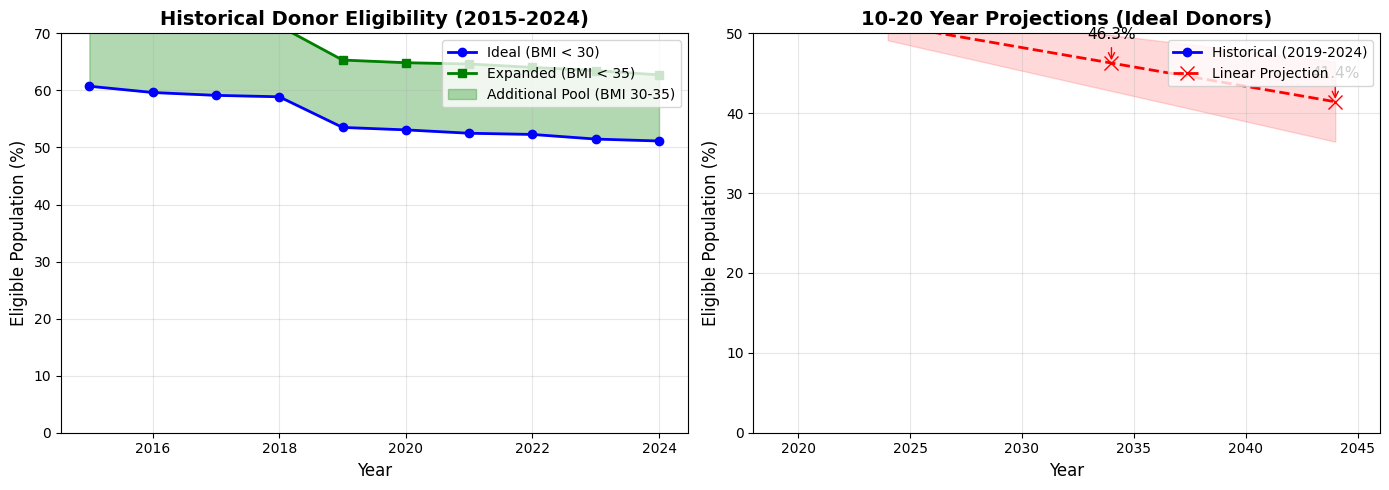


📉 If current trends continue:
   • 2034: 46.3% eligible (~120M people)
   • 2044: 41.4% eligible (~108M people)


In [4]:
# Visualization: Donor Eligibility Trends & Projections
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Historical Trends
ax1 = axes[0]
ax1.plot(eligibility_df["Year"], eligibility_df["Ideal % (BMI<30)"], 
         marker="o", linewidth=2, color="blue", label="Ideal (BMI < 30)")
ax1.plot(eligibility_df["Year"], eligibility_df["Expanded % (BMI<35)"], 
         marker="s", linewidth=2, color="green", label="Expanded (BMI < 35)")
ax1.fill_between(eligibility_df["Year"], 
                 eligibility_df["Ideal % (BMI<30)"], 
                 eligibility_df["Expanded % (BMI<35)"],
                 alpha=0.3, color="green", label="Additional Pool (BMI 30-35)")

ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Eligible Population (%)", fontsize=12)
ax1.set_title("Historical Donor Eligibility (2015-2024)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 70)

# Plot 2: Projections
ax2 = axes[1]
# Historical data from 2019
recent = eligibility_df[eligibility_df["Year"] >= 2019]
ax2.plot(recent["Year"], recent["Ideal % (BMI<30)"], 
         marker="o", linewidth=2, color="blue", label="Historical (2019-2024)")

# Projection line
all_proj_years = [2024] + PROJECTION_YEARS[1:]
all_proj_vals = [baseline_pct] + list(proj_vals[1:])
ax2.plot(all_proj_years, all_proj_vals, 
         linestyle="--", marker="x", markersize=10, linewidth=2, 
         color="red", label="Linear Projection")

# Shade projection uncertainty
ax2.fill_between([2024, 2044], 
                 [all_proj_vals[0] - 2, all_proj_vals[-1] - 5],
                 [all_proj_vals[0] + 2, all_proj_vals[-1] + 5],
                 alpha=0.15, color="red")

# Add annotations
ax2.annotate(f'{proj_vals[1]:.1f}%', xy=(2034, proj_vals[1]), 
             xytext=(2034, proj_vals[1]+3), fontsize=11, ha='center',
             arrowprops=dict(arrowstyle='->', color='red'))
ax2.annotate(f'{proj_vals[2]:.1f}%', xy=(2044, proj_vals[2]), 
             xytext=(2044, proj_vals[2]+3), fontsize=11, ha='center',
             arrowprops=dict(arrowstyle='->', color='red'))

ax2.set_xlabel("Year", fontsize=12)
ax2.set_ylabel("Eligible Population (%)", fontsize=12)
ax2.set_title("10-20 Year Projections (Ideal Donors)", fontsize=14, fontweight="bold")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2018, 2046)
ax2.set_ylim(0, 50)

plt.tight_layout()
plt.savefig("../output/eligibility_trends.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📉 If current trends continue:")
print(f"   • 2034: {proj_vals[1]:.1f}% eligible (~{proj_2034_count/1e6:.0f}M people)")
print(f"   • 2044: {proj_vals[2]:.1f}% eligible (~{proj_2044_count/1e6:.0f}M people)")

In [ ]:
## Section 3: Marginal/Potential Donor Categories

**All marginal donors have NO DIABETES.** Three binary variables create 8 combinations, but we exclude those with HTN + Prediabetes + Obesity (not donor candidates). This leaves 7 categories:

| HTN | Prediabetes | Obesity (BMI 30-35) | Category |
|-----|-------------|---------------------|----------|
| No  | No          | No                  | Ideal Donor (BMI < 30) |
| No  | No          | Yes                 | Obesity Only |
| No  | Yes         | No                  | Prediabetes Only |
| No  | Yes         | Yes                 | Prediabetes + Obesity |
| Yes | No          | No                  | HTN Only |
| Yes | No          | Yes                 | HTN + Obesity |
| Yes | Yes         | No                  | HTN + Prediabetes |
| Yes | Yes         | Yes                 | **EXCLUDED** (Not donor candidate) |

,metric,value
0,Latest year,2024.000000
1,Ideal % (BMI < 30),51.131865
2,Expanded % (BMI < 35),62.715646
3,Additional % points,11.583781
4,Ideal count (millions),116.532445
5,Expanded count (millions),142.932545
6,Additional count (millions),26.400100


In [5]:
# Calculate Marginal Donor Categories (Latest Year)
latest_year = max(years)
df = dataframes[latest_year]

# Base condition: No Diabetes
no_diabetes = df["diabetes"] != 1

# Binary conditions
htn = df["hypertension"] == 1
predm = df["prediabetes"] == 1
obese_30_35 = (df["BMI"] >= 30) & (df["BMI"] < 35)

# Define all 7 categories
categories = [
    ("No", "No", "No", "Ideal Donor (BMI<30)", 
     no_diabetes & ~htn & ~predm & (df["BMI"] < 30)),
    ("No", "No", "Yes", "Obesity Only (BMI 30-35)", 
     no_diabetes & ~htn & ~predm & obese_30_35),
    ("No", "Yes", "No", "Prediabetes Only", 
     no_diabetes & ~htn & predm & (df["BMI"] < 30)),
    ("No", "Yes", "Yes", "Prediabetes + Obesity", 
     no_diabetes & ~htn & predm & obese_30_35),
    ("Yes", "No", "No", "HTN Only", 
     no_diabetes & htn & ~predm & (df["BMI"] < 30)),
    ("Yes", "No", "Yes", "HTN + Obesity", 
     no_diabetes & htn & ~predm & obese_30_35),
    ("Yes", "Yes", "No", "HTN + Prediabetes", 
     no_diabetes & htn & predm & (df["BMI"] < 30)),
]

# Calculate stats for each category
marginal_rows = []
total_weight = df["survey_weight"].sum()

for htn_val, predm_val, obese_val, category_name, mask in categories:
    subset_weight = df.loc[mask, "survey_weight"].sum()
    pct = (subset_weight / total_weight) * 100
    n_millions = subset_weight / 1_000_000
    n_scaled = (pct / 100) * US_ADULT_POPULATION_2025 / 1_000_000  # Scale to US pop
    
    marginal_rows.append({
        "HTN": htn_val,
        "Prediabetes": predm_val,
        "Obesity (30-35)": obese_val,
        "Category": category_name,
        "% of Adults": round(pct, 2),
        "Est. US Adults (M)": round(n_scaled, 1),
    })

marginal_df = pd.DataFrame(marginal_rows)

# Add total row
total_pct = marginal_df["% of Adults"].sum()
total_n = marginal_df["Est. US Adults (M)"].sum()
marginal_df.loc[len(marginal_df)] = ["—", "—", "—", "TOTAL POTENTIAL DONORS", 
                                      round(total_pct, 2), round(total_n, 1)]

print(f"MARGINAL DONOR CATEGORIES ({latest_year})")
print("=" * 70)
print(f"All categories exclude diabetes. US Adult Population = {US_ADULT_POPULATION_2025/1e6:.0f}M")
print()
marginal_df

MARGINAL DONOR CATEGORIES (2024)
All categories exclude diabetes. US Adult Population = 260M



,HTN,Prediabetes,Obesity (30-35),Category,% of Adults,Est. US Adults (M)
0,No,No,No,Ideal Donor (BMI<30),51.13,132.9
1,No,No,Yes,Obesity Only (BMI 30-35),11.58,30.1
2,No,Yes,No,Prediabetes Only,3.12,8.1
3,No,Yes,Yes,Prediabetes + Obesity,1.73,4.5
4,Yes,No,No,HTN Only,8.23,21.4
5,Yes,No,Yes,HTN + Obesity,3.12,8.1
6,Yes,Yes,No,HTN + Prediabetes,1.75,4.5
7,—,—,—,TOTAL POTENTIAL DONORS,80.66,209.6


In [ ]:
# Data-Driven Venn Diagram: HTN, Prediabetes, Obesity (Among Non-Diabetics, BMI < 35)
# NOTE: This Venn uses percentages of ALL ADULTS (not just the filtered pool)
# to be consistent with the marginal_df table above.
from matplotlib_venn import venn3, venn3_circles

df_latest = dataframes[max(years)]
total_weight = df_latest["survey_weight"].sum()

# Base condition: No Diabetes
no_dm = df_latest["diabetes"] != 1

# Define the three conditions
A = df_latest["hypertension"] == 1        # HTN
B = df_latest["prediabetes"] == 1         # Prediabetes
C = (df_latest["BMI"] >= 30) & (df_latest["BMI"] < 35)  # Obesity (BMI 30-35)

# Calculate weighted % of ALL adults for each Venn region
def weighted_pct_all(mask):
    """% of ALL adults (not just non-diabetic pool)."""
    return (df_latest.loc[mask, "survey_weight"].sum() / total_weight) * 100

# 7 regions of the Venn diagram + ideal + excluded
only_A = no_dm & A & ~B & ~C     # HTN only
only_B = no_dm & ~A & B & ~C     # Prediabetes only
only_C = no_dm & ~A & ~B & C     # Obesity only
A_and_B = no_dm & A & B & ~C     # HTN + Prediabetes
A_and_C = no_dm & A & ~B & C     # HTN + Obesity
B_and_C = no_dm & ~A & B & C     # Prediabetes + Obesity
all_three = no_dm & A & B & C    # All three (excluded from donors)
none = no_dm & ~A & ~B & (df_latest["BMI"] < 30)  # Ideal donors

# Calculate percentages (of ALL adults)
venn_values = {
    'only_htn': weighted_pct_all(only_A),
    'only_predm': weighted_pct_all(only_B),
    'only_obese': weighted_pct_all(only_C),
    'htn_predm': weighted_pct_all(A_and_B),
    'htn_obese': weighted_pct_all(A_and_C),
    'predm_obese': weighted_pct_all(B_and_C),
    'all_three': weighted_pct_all(all_three),
    'none_ideal': weighted_pct_all(none)
}

# Convert to millions
pop_factor = US_ADULT_POPULATION_2025 / 1_000_000
venn_millions = {k: (v/100) * pop_factor for k, v in venn_values.items()}

# Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left plot: Venn diagram
ax1 = axes[0]
# venn3 expects: (Abc, aBc, ABc, abC, AbC, aBC, ABC)
venn_subsets = (
    venn_values['only_htn'],
    venn_values['only_predm'],
    venn_values['htn_predm'],
    venn_values['only_obese'],
    venn_values['htn_obese'],
    venn_values['predm_obese'],
    venn_values['all_three']
)

v = venn3(subsets=venn_subsets,
          set_labels=('HTN', 'Prediabetes', 'Obesity\n(BMI 30-35)'),
          ax=ax1)

# Customize colors
colors_map = {'100': '#3498db', '010': '#e74c3c', '001': '#f39c12',
              '110': '#9b59b6', '101': '#2980b9', '011': '#c0392b', '111': '#7f8c8d'}
for pid, color in colors_map.items():
    if v.get_patch_by_id(pid):
        v.get_patch_by_id(pid).set_color(color)
        v.get_patch_by_id(pid).set_alpha(0.7)

# Update labels with percentages (of all adults)
for pid, val in zip(['100', '010', '110', '001', '101', '011', '111'], venn_subsets):
    if v.get_label_by_id(pid):
        v.get_label_by_id(pid).set_text(f'{val:.1f}%')
        v.get_label_by_id(pid).set_fontsize(11)
        v.get_label_by_id(pid).set_fontweight('bold')

venn3_circles(subsets=venn_subsets, ax=ax1, linewidth=2)

# Add ideal donors annotation (outside the circles)
ax1.text(0.5, -0.35,
         f"IDEAL DONORS (No DM, No HTN, No Pre-DM, BMI<30): "
         f"{venn_values['none_ideal']:.1f}% ({venn_millions['none_ideal']:.1f}M)",
         ha='center', fontsize=12, fontweight='bold', color='green',
         transform=ax1.transAxes,
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
ax1.text(0.5, -0.42, 'All percentages are % of ALL US adults',
         ha='center', fontsize=9, color='gray', transform=ax1.transAxes)

ax1.set_title(f"Non-Diabetic Marginal Donor Conditions ({max(years)})",
              fontsize=14, fontweight='bold')

# Right plot: Summary table
ax2 = axes[1]
ax2.axis('off')

summary_data = [
    ["Category", "% of All Adults", "Est. US (M)", "Donor Status"],
    ["-" * 15, "-" * 12, "-" * 10, "-" * 15],
    ["None (Ideal, BMI<30)", f"{venn_values['none_ideal']:.1f}%", f"{venn_millions['none_ideal']:.1f}M", "IDEAL"],
    ["Obesity Only", f"{venn_values['only_obese']:.1f}%", f"{venn_millions['only_obese']:.1f}M", "Expanded"],
    ["Prediabetes Only", f"{venn_values['only_predm']:.1f}%", f"{venn_millions['only_predm']:.1f}M", "Marginal"],
    ["HTN Only", f"{venn_values['only_htn']:.1f}%", f"{venn_millions['only_htn']:.1f}M", "Marginal"],
    ["HTN + Prediabetes", f"{venn_values['htn_predm']:.1f}%", f"{venn_millions['htn_predm']:.1f}M", "Marginal"],
    ["HTN + Obesity", f"{venn_values['htn_obese']:.1f}%", f"{venn_millions['htn_obese']:.1f}M", "Marginal"],
    ["Predm + Obesity", f"{venn_values['predm_obese']:.1f}%", f"{venn_millions['predm_obese']:.1f}M", "Marginal"],
    ["-" * 15, "-" * 12, "-" * 10, "-" * 15],
    ["HTN+Predm+Obesity", f"{venn_values['all_three']:.1f}%", f"{venn_millions['all_three']:.1f}M", "EXCLUDED"],
]

table_text = "\n".join([f"{row[0]:<22} {row[1]:<14} {row[2]:<12} {row[3]}" for row in summary_data])
ax2.text(0.05, 0.95, table_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))

ax2.text(0.05, 0.25,
         f"Population Base: ALL US Adults\n"
         f"Data Source: NHIS {max(years)}\n"
         f"US Adult Pop Est: {US_ADULT_POPULATION_2025/1e6:.0f}M",
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig("../output/donor_venn_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nVenn Diagram Summary (% of ALL adults, Non-Diabetic conditions):")
for k, v in venn_values.items():
    print(f"   {k}: {v:.2f}% ({venn_millions[k]:.1f}M)")

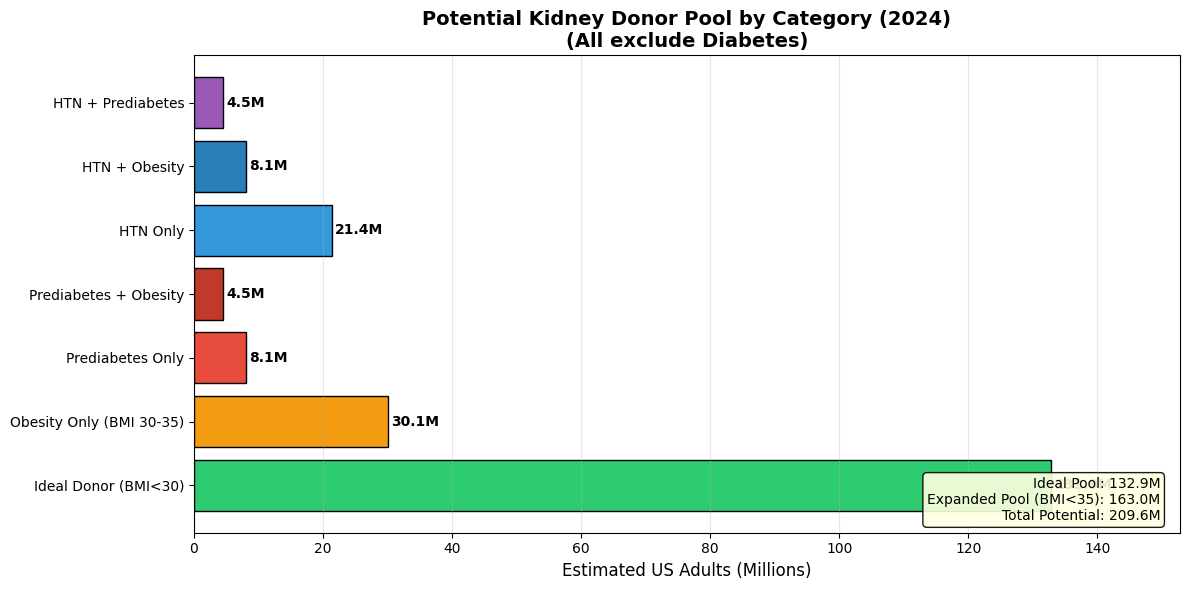

In [7]:
# Bar Chart: Marginal Donor Categories
fig, ax = plt.subplots(figsize=(12, 6))

# Exclude total row for plotting
plot_df = marginal_df[marginal_df["Category"] != "TOTAL POTENTIAL DONORS"].copy()

# Color coding
colors = ["#2ecc71",  # Ideal - green
          "#f39c12",  # Obesity only - orange
          "#e74c3c",  # Prediabetes only - red
          "#c0392b",  # Prediabetes + Obesity - dark red
          "#3498db",  # HTN only - blue
          "#2980b9",  # HTN + Obesity - darker blue
          "#9b59b6"]  # HTN + Prediabetes - purple

bars = ax.barh(plot_df["Category"], plot_df["Est. US Adults (M)"], color=colors, edgecolor="black")

# Add value labels
for bar, val in zip(bars, plot_df["Est. US Adults (M)"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f"{val:.1f}M", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("Estimated US Adults (Millions)", fontsize=12)
ax.set_title(f"Potential Kidney Donor Pool by Category ({latest_year})\n(All exclude Diabetes)", 
             fontsize=14, fontweight="bold")
ax.set_xlim(0, max(plot_df["Est. US Adults (M)"]) * 1.15)
ax.grid(axis="x", alpha=0.3)

# Add annotation
ideal_n = plot_df[plot_df["Category"] == "Ideal Donor (BMI<30)"]["Est. US Adults (M)"].values[0]
expanded_n = plot_df[plot_df["Category"].isin(["Ideal Donor (BMI<30)", "Obesity Only (BMI 30-35)"])]["Est. US Adults (M)"].sum()
ax.text(0.98, 0.02, 
        f"Ideal Pool: {ideal_n:.1f}M\nExpanded Pool (BMI<35): {expanded_n:.1f}M\nTotal Potential: {total_n:.1f}M",
        transform=ax.transAxes, fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()
plt.savefig("../output/marginal_donors_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 5: NHANES Comparison (Lab-Based Validation)

NHIS relies on self-reported health conditions. NHANES provides lab-based measurements for validation:
- **HbA1c & Fasting Glucose** for diabetes/prediabetes diagnosis
- **Blood Pressure measurements** (actual readings)
- **BMI from measured height/weight**

Compare NHIS (self-report, 2024) vs NHANES (lab-based, 2021-2022).

In [ ]:
# Load NHANES 2021-2022 Data (Lab-based measurements)
NHANES_PATH = os.path.join(project_root, "nhanes_data")

# Load all NHANES files
demo = pd.read_sas(os.path.join(NHANES_PATH, "DEMO_L.xpt"))
ghb = pd.read_sas(os.path.join(NHANES_PATH, "GHB_L.xpt"))   # HbA1c
glu = pd.read_sas(os.path.join(NHANES_PATH, "GLU_L.xpt"))   # Fasting glucose
bmx = pd.read_sas(os.path.join(NHANES_PATH, "BMX_L.xpt"))   # Body Measures (BMI)
bpq = pd.read_sas(os.path.join(NHANES_PATH, "BPQ_L.xpt"))   # Blood Pressure Questionnaire
diq = pd.read_sas(os.path.join(NHANES_PATH, "DIQ_L.xpt"))   # Diabetes Questionnaire

# Merge by participant ID (SEQN)
nhanes_df = demo.merge(ghb, on="SEQN", how="left") \
                .merge(glu, on="SEQN", how="left") \
                .merge(bmx, on="SEQN", how="left") \
                .merge(bpq, on="SEQN", how="left") \
                .merge(diq, on="SEQN", how="left")

# --- Define conditions using LAB values ---

# 1. Diabetes (Lab-based OR self-reported)
# Lab: HbA1c >= 6.5% OR Fasting Glucose >= 126 mg/dL
# Questionnaire: DIQ010 == 1 (Doctor told you have diabetes)
nhanes_df["diabetes_lab"] = (
    (nhanes_df["LBXGH"] >= 6.5) | 
    (nhanes_df["LBXGLU"] >= 126)
)
nhanes_df["diabetes"] = (
    (nhanes_df["diabetes_lab"]) | 
    (nhanes_df["DIQ010"] == 1)
).astype(float)

# 2. Prediabetes (Lab-based OR self-reported)
# Lab: HbA1c 5.7-6.4% OR Fasting Glucose 100-125 mg/dL
# Questionnaire: DIQ160 == 1 (Doctor told you have prediabetes)
nhanes_df["prediabetes_lab"] = (
    ((nhanes_df["LBXGH"] >= 5.7) & (nhanes_df["LBXGH"] < 6.5)) |
    ((nhanes_df["LBXGLU"] >= 100) & (nhanes_df["LBXGLU"] < 126))
)
nhanes_df["prediabetes"] = (
    (nhanes_df["prediabetes_lab"]) | 
    (nhanes_df["DIQ160"] == 1)
).astype(float)

# 3. Hypertension (Self-reported - BPQ020 == 1)
nhanes_df["hypertension"] = (nhanes_df["BPQ020"] == 1).astype(float)

# 4. BMI (measured)
nhanes_df["BMI"] = nhanes_df["BMXBMI"]

# 5. Survey Weight (fasting subsample)
weight_col = "WTSAF2YR" if "WTSAF2YR" in nhanes_df.columns else "WTSAFPRP"
nhanes_df["survey_weight"] = nhanes_df[weight_col]

# Filter to Adults (Age >= 18) with valid weights and BMI
nhanes_df = nhanes_df[
    (nhanes_df["RIDAGEYR"] >= 18) & 
    (nhanes_df["survey_weight"] > 0) &
    (nhanes_df["BMI"].notna())
].copy()

print(f"NHANES 2021-2022 Loaded: {nhanes_df.shape[0]} adults with valid data")
print(f"Lab-based diabetes detection available: {nhanes_df['diabetes_lab'].notna().sum()} participants")
print(f"Lab-based prediabetes detection available: {nhanes_df['prediabetes_lab'].notna().sum()} participants")

In [12]:
# Calculate NHANES Donor Eligibility (Same methodology as NHIS)
def calc_nhanes_eligibility(nhanes_df, bmi_max=30):
    """Calculate eligibility: No DM + No PreDM + No HTN + BMI < threshold"""
    mask = (
        (nhanes_df["diabetes"] != 1) &
        (nhanes_df["prediabetes"] != 1) &
        (nhanes_df["hypertension"] != 1) &
        (nhanes_df["BMI"] < bmi_max)
    )
    weights = nhanes_df["survey_weight"]
    return (mask.astype(float) * weights).sum() / weights.sum() * 100

# Calculate NHANES eligibility rates
nhanes_ideal_pct = calc_nhanes_eligibility(nhanes_df, bmi_max=30)
nhanes_expanded_pct = calc_nhanes_eligibility(nhanes_df, bmi_max=35)

# Get NHIS 2024 values for comparison (closest year to NHANES 2021-2022)
nhis_2024 = eligibility_df[eligibility_df["Year"] == 2024].iloc[0]
nhis_2021 = eligibility_df[eligibility_df["Year"] == 2021].iloc[0]

# Build comparison table
comparison_df = pd.DataFrame({
    "Metric": [
        "Ideal Donors (BMI < 30)",
        "Expanded Donors (BMI < 35)",
        "Additional (BMI 30-35)"
    ],
    "NHIS 2021 (Self-Report)": [
        f"{nhis_2021['Ideal % (BMI<30)']:.1f}%",
        f"{nhis_2021['Expanded % (BMI<35)']:.1f}%",
        f"{nhis_2021['Additional % (BMI 30-35)']:.1f}%"
    ],
    "NHANES 2021-22 (Lab-Based)": [
        f"{nhanes_ideal_pct:.1f}%",
        f"{nhanes_expanded_pct:.1f}%",
        f"{nhanes_expanded_pct - nhanes_ideal_pct:.1f}%"
    ],
    "NHIS 2024 (Self-Report)": [
        f"{nhis_2024['Ideal % (BMI<30)']:.1f}%",
        f"{nhis_2024['Expanded % (BMI<35)']:.1f}%",
        f"{nhis_2024['Additional % (BMI 30-35)']:.1f}%"
    ],
    "Difference (NHANES vs NHIS 2021)": [
        f"{nhanes_ideal_pct - nhis_2021['Ideal % (BMI<30)']:+.1f} pp",
        f"{nhanes_expanded_pct - nhis_2021['Expanded % (BMI<35)']:+.1f} pp",
        f"{(nhanes_expanded_pct - nhanes_ideal_pct) - nhis_2021['Additional % (BMI 30-35)']:+.1f} pp"
    ]
})

print("=" * 80)
print("NHIS vs NHANES COMPARISON: Donor Eligibility Rates")
print("=" * 80)
print("NHIS: Self-reported conditions | NHANES: Lab-based + self-reported")
print()
comparison_df

NHIS vs NHANES COMPARISON: Donor Eligibility Rates
NHIS: Self-reported conditions | NHANES: Lab-based + self-reported



,Metric,NHIS 2021 (Self-Report),NHANES 2021-22 (Lab-Based),NHIS 2024 (Self-Report),Difference (NHANES vs NHIS 2021)
0,Ideal Donors (BMI < 30),52.5%,26.2%,51.1%,-26.3 pp
1,Expanded Donors (BMI < 35),64.6%,30.8%,62.7%,-33.8 pp
2,Additional (BMI 30-35),12.1%,4.6%,11.6%,-7.5 pp


In [13]:
# NHANES: Calculate Marginal Donor Categories (Venn Diagram Data)
nhanes_pool = nhanes_df[(nhanes_df["diabetes"] != 1) & (nhanes_df["BMI"] < 35)].copy()
nhanes_total_weight = nhanes_pool["survey_weight"].sum()

# Define conditions for NHANES
nhanes_htn = nhanes_pool["hypertension"] == 1
nhanes_predm = nhanes_pool["prediabetes"] == 1
nhanes_obese = (nhanes_pool["BMI"] >= 30) & (nhanes_pool["BMI"] < 35)

def nhanes_weighted_pct(mask):
    return (nhanes_pool.loc[mask, "survey_weight"].sum() / nhanes_total_weight) * 100

# Calculate all 8 regions for NHANES
nhanes_venn = {
    'none_ideal': nhanes_weighted_pct(~nhanes_htn & ~nhanes_predm & ~nhanes_obese),
    'only_obese': nhanes_weighted_pct(~nhanes_htn & ~nhanes_predm & nhanes_obese),
    'only_predm': nhanes_weighted_pct(~nhanes_htn & nhanes_predm & ~nhanes_obese),
    'only_htn': nhanes_weighted_pct(nhanes_htn & ~nhanes_predm & ~nhanes_obese),
    'predm_obese': nhanes_weighted_pct(~nhanes_htn & nhanes_predm & nhanes_obese),
    'htn_obese': nhanes_weighted_pct(nhanes_htn & ~nhanes_predm & nhanes_obese),
    'htn_predm': nhanes_weighted_pct(nhanes_htn & nhanes_predm & ~nhanes_obese),
    'all_three': nhanes_weighted_pct(nhanes_htn & nhanes_predm & nhanes_obese),
}

# Build side-by-side comparison with NHIS
comparison_categories = pd.DataFrame({
    "Category": [
        "Ideal (No HTN, No PreDM, BMI<30)",
        "Obesity Only (BMI 30-35)",
        "Prediabetes Only",
        "HTN Only",
        "Prediabetes + Obesity",
        "HTN + Obesity",
        "HTN + Prediabetes",
        "HTN + PreDM + Obesity (Excluded)"
    ],
    "NHIS 2024 (%)": [
        venn_values['none_ideal'],
        venn_values['only_obese'],
        venn_values['only_predm'],
        venn_values['only_htn'],
        venn_values['predm_obese'],
        venn_values['htn_obese'],
        venn_values['htn_predm'],
        venn_values['all_three']
    ],
    "NHANES 2021-22 (%)": [
        nhanes_venn['none_ideal'],
        nhanes_venn['only_obese'],
        nhanes_venn['only_predm'],
        nhanes_venn['only_htn'],
        nhanes_venn['predm_obese'],
        nhanes_venn['htn_obese'],
        nhanes_venn['htn_predm'],
        nhanes_venn['all_three']
    ]
})

comparison_categories["Difference (pp)"] = comparison_categories["NHANES 2021-22 (%)"] - comparison_categories["NHIS 2024 (%)"]
comparison_categories["NHIS 2024 (%)"] = comparison_categories["NHIS 2024 (%)"].round(2)
comparison_categories["NHANES 2021-22 (%)"] = comparison_categories["NHANES 2021-22 (%)"].round(2)
comparison_categories["Difference (pp)"] = comparison_categories["Difference (pp)"].round(2)

print("MARGINAL DONOR CATEGORIES: NHIS vs NHANES")
print("=" * 70)
print("(Among non-diabetic adults with BMI < 35)")
print()
comparison_categories

MARGINAL DONOR CATEGORIES: NHIS vs NHANES
(Among non-diabetic adults with BMI < 35)



,Category,NHIS 2024 (%),NHANES 2021-22 (%),Difference (pp)
0,"Ideal (No HTN, No PreDM, BMI<30)",62.52,36.69,-25.83
1,Obesity Only (BMI 30-35),14.16,6.47,-7.69
2,Prediabetes Only,3.82,24.93,21.11
3,HTN Only,10.06,4.49,-5.57
4,Prediabetes + Obesity,2.11,9.44,7.32
5,HTN + Obesity,3.81,2.25,-1.57
6,HTN + Prediabetes,2.14,10.40,8.26
7,HTN + PreDM + Obesity (Excluded),1.37,5.33,3.96


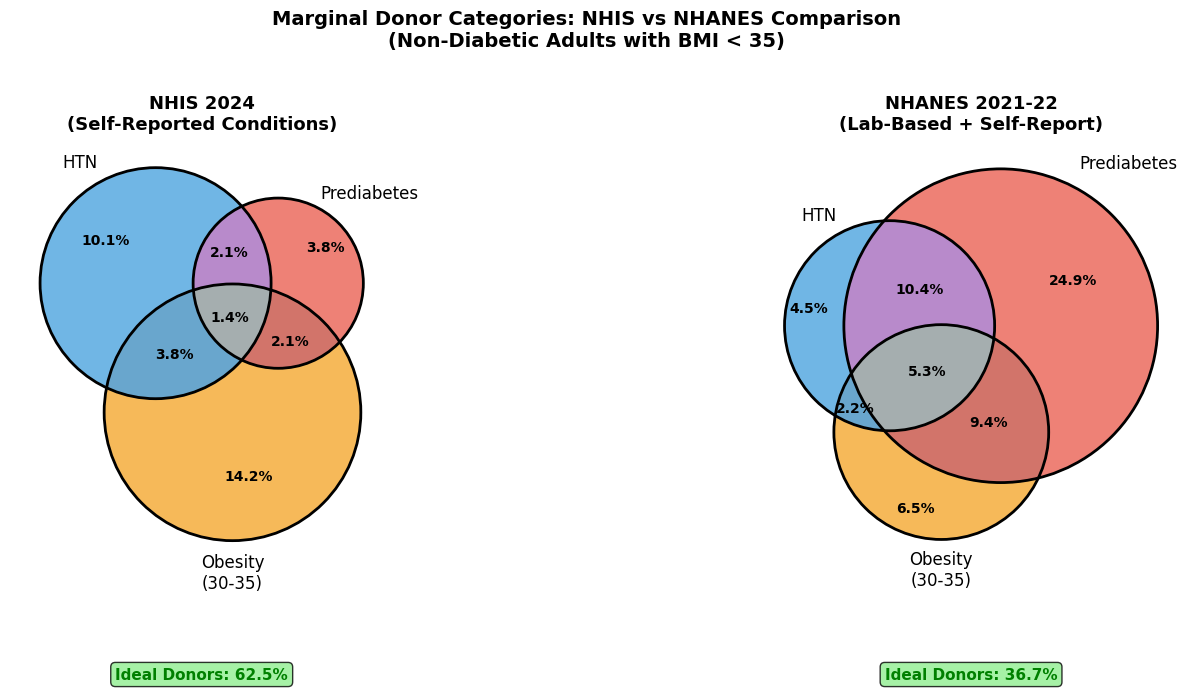


📊 Key Finding: NHANES lab-based detection shows:
   • Ideal donors: 36.7% (NHANES) vs 62.5% (NHIS)
   • Difference: -25.8 percentage points


In [14]:
# Visualization: Side-by-side Venn Diagrams (NHIS vs NHANES)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Helper function to create Venn diagram
def create_venn(ax, venn_data, title, pop_millions):
    subsets = (
        venn_data['only_htn'],
        venn_data['only_predm'],
        venn_data['htn_predm'],
        venn_data['only_obese'],
        venn_data['htn_obese'],
        venn_data['predm_obese'],
        venn_data['all_three']
    )
    
    v = venn3(subsets=subsets, 
              set_labels=('HTN', 'Prediabetes', 'Obesity\n(30-35)'),
              ax=ax)
    
    # Set colors
    colors_map = {'100': '#3498db', '010': '#e74c3c', '001': '#f39c12',
                  '110': '#9b59b6', '101': '#2980b9', '011': '#c0392b', '111': '#7f8c8d'}
    
    for pid, color in colors_map.items():
        if v.get_patch_by_id(pid):
            v.get_patch_by_id(pid).set_color(color)
            v.get_patch_by_id(pid).set_alpha(0.7)
    
    # Update labels
    for pid, val in zip(['100', '010', '110', '001', '101', '011', '111'], subsets):
        if v.get_label_by_id(pid):
            v.get_label_by_id(pid).set_text(f'{val:.1f}%')
            v.get_label_by_id(pid).set_fontsize(10)
            v.get_label_by_id(pid).set_fontweight('bold')
    
    venn3_circles(subsets=subsets, ax=ax, linewidth=2)
    
    # Add ideal donors annotation
    ax.text(0.5, -0.25, f"Ideal Donors: {venn_data['none_ideal']:.1f}%",
            ha='center', fontsize=11, fontweight='bold', color='green',
            transform=ax.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    ax.set_title(title, fontsize=13, fontweight='bold')

# Left: NHIS 2024
create_venn(axes[0], venn_values, "NHIS 2024\n(Self-Reported Conditions)", pop_factor)

# Right: NHANES 2021-22
create_venn(axes[1], nhanes_venn, "NHANES 2021-22\n(Lab-Based + Self-Report)", pop_factor)

plt.suptitle("Marginal Donor Categories: NHIS vs NHANES Comparison\n(Non-Diabetic Adults with BMI < 35)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../output/nhis_vs_nhanes_venn.png", dpi=150, bbox_inches="tight")
plt.show()

# Print key difference
print(f"\n📊 Key Finding: NHANES lab-based detection shows:")
print(f"   • Ideal donors: {nhanes_venn['none_ideal']:.1f}% (NHANES) vs {venn_values['none_ideal']:.1f}% (NHIS)")
print(f"   • Difference: {nhanes_venn['none_ideal'] - venn_values['none_ideal']:+.1f} percentage points")

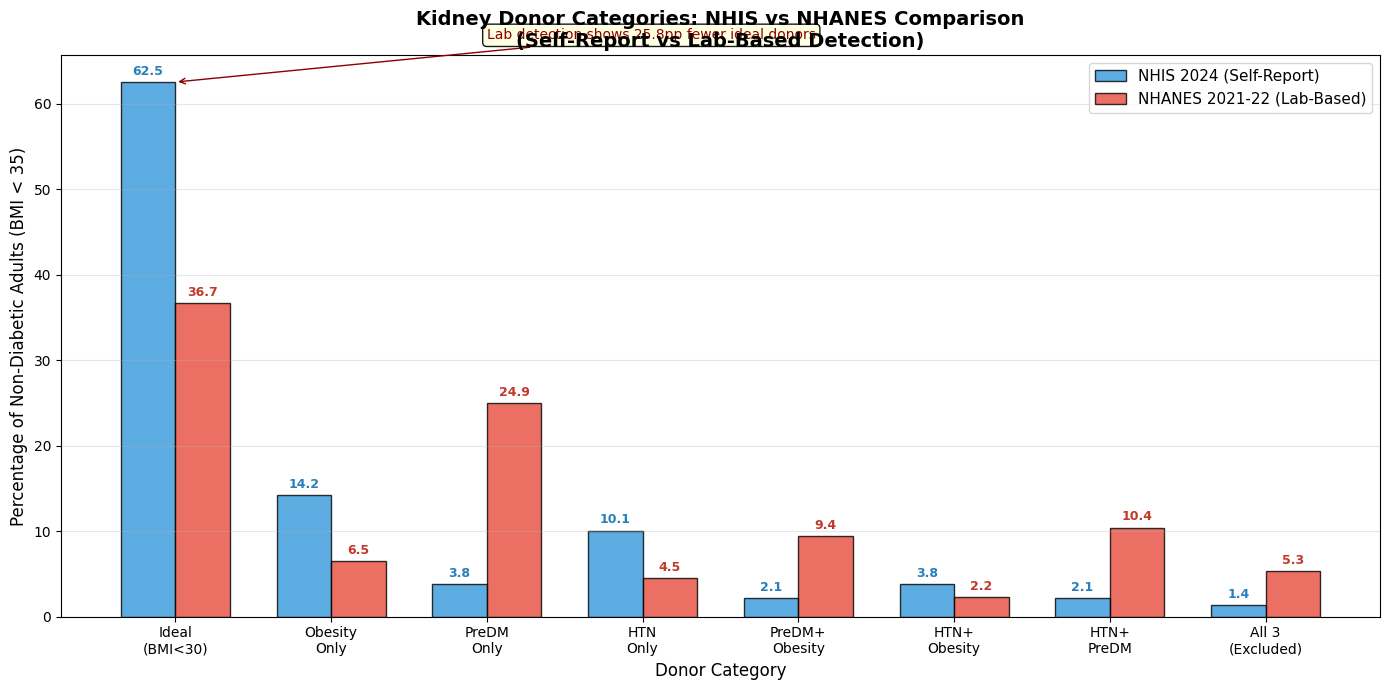

In [15]:
# Bar Chart Comparison: NHIS vs NHANES by Category
fig, ax = plt.subplots(figsize=(14, 7))

categories_short = [
    "Ideal\n(BMI<30)", "Obesity\nOnly", "PreDM\nOnly", "HTN\nOnly",
    "PreDM+\nObesity", "HTN+\nObesity", "HTN+\nPreDM", "All 3\n(Excluded)"
]

x = np.arange(len(categories_short))
width = 0.35

nhis_vals = [venn_values['none_ideal'], venn_values['only_obese'], venn_values['only_predm'],
             venn_values['only_htn'], venn_values['predm_obese'], venn_values['htn_obese'],
             venn_values['htn_predm'], venn_values['all_three']]

nhanes_vals = [nhanes_venn['none_ideal'], nhanes_venn['only_obese'], nhanes_venn['only_predm'],
               nhanes_venn['only_htn'], nhanes_venn['predm_obese'], nhanes_venn['htn_obese'],
               nhanes_venn['htn_predm'], nhanes_venn['all_three']]

bars1 = ax.bar(x - width/2, nhis_vals, width, label='NHIS 2024 (Self-Report)', 
               color='#3498db', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, nhanes_vals, width, label='NHANES 2021-22 (Lab-Based)', 
               color='#e74c3c', edgecolor='black', alpha=0.8)

# Add value labels
for bar, val in zip(bars1, nhis_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2980b9')
for bar, val in zip(bars2, nhanes_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#c0392b')

ax.set_xlabel('Donor Category', fontsize=12)
ax.set_ylabel('Percentage of Non-Diabetic Adults (BMI < 35)', fontsize=12)
ax.set_title('Kidney Donor Categories: NHIS vs NHANES Comparison\n(Self-Report vs Lab-Based Detection)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories_short, fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add annotation about key difference
diff_ideal = nhanes_venn['none_ideal'] - venn_values['none_ideal']
ax.annotate(f"Lab detection shows {abs(diff_ideal):.1f}pp {'fewer' if diff_ideal < 0 else 'more'} ideal donors",
            xy=(0, max(nhis_vals[0], nhanes_vals[0])), 
            xytext=(2, max(nhis_vals[0], nhanes_vals[0]) + 5),
            fontsize=10, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'),
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig("../output/nhis_vs_nhanes_bars.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# NHANES: Lab vs Self-Report Detection Differences
# Compare how many people are identified by LAB vs QUESTIONNAIRE

# Among all NHANES adults
nhanes_all = nhanes_df.copy()

# Diabetes detection comparison
dm_lab_only = (nhanes_all["diabetes_lab"] == True) & (nhanes_all["DIQ010"] != 1)
dm_self_only = (nhanes_all["diabetes_lab"] != True) & (nhanes_all["DIQ010"] == 1)
dm_both = (nhanes_all["diabetes_lab"] == True) & (nhanes_all["DIQ010"] == 1)

dm_lab_pct = (dm_lab_only.astype(float) * nhanes_all["survey_weight"]).sum() / nhanes_all["survey_weight"].sum() * 100
dm_self_pct = (dm_self_only.astype(float) * nhanes_all["survey_weight"]).sum() / nhanes_all["survey_weight"].sum() * 100
dm_both_pct = (dm_both.astype(float) * nhanes_all["survey_weight"]).sum() / nhanes_all["survey_weight"].sum() * 100

# Prediabetes detection comparison
predm_lab_only = (nhanes_all["prediabetes_lab"] == True) & (nhanes_all["DIQ160"] != 1)
predm_self_only = (nhanes_all["prediabetes_lab"] != True) & (nhanes_all["DIQ160"] == 1)
predm_both = (nhanes_all["prediabetes_lab"] == True) & (nhanes_all["DIQ160"] == 1)

predm_lab_pct = (predm_lab_only.astype(float) * nhanes_all["survey_weight"]).sum() / nhanes_all["survey_weight"].sum() * 100
predm_self_pct = (predm_self_only.astype(float) * nhanes_all["survey_weight"]).sum() / nhanes_all["survey_weight"].sum() * 100
predm_both_pct = (predm_both.astype(float) * nhanes_all["survey_weight"]).sum() / nhanes_all["survey_weight"].sum() * 100

detection_df = pd.DataFrame({
    "Condition": ["Diabetes", "Diabetes", "Diabetes", "Prediabetes", "Prediabetes", "Prediabetes"],
    "Detection Method": ["Lab Only (Undiagnosed)", "Self-Report Only", "Both (Confirmed)", 
                         "Lab Only (Undiagnosed)", "Self-Report Only", "Both (Confirmed)"],
    "% of Adults": [dm_lab_pct, dm_self_pct, dm_both_pct, predm_lab_pct, predm_self_pct, predm_both_pct]
})

print("=" * 70)
print("NHANES: LAB vs SELF-REPORT DETECTION (Undiagnosed Disease)")
print("=" * 70)
print(f"\n⚠️  UNDIAGNOSED CASES (Lab-positive but self-report negative):")
print(f"   • Undiagnosed Diabetes: {dm_lab_pct:.1f}% of US adults (~{dm_lab_pct/100 * US_ADULT_POPULATION_2025/1e6:.1f}M)")
print(f"   • Undiagnosed Prediabetes: {predm_lab_pct:.1f}% of US adults (~{predm_lab_pct/100 * US_ADULT_POPULATION_2025/1e6:.1f}M)")
print(f"\n📊 This means NHIS (self-report only) may OVERESTIMATE ideal donors by missing")
print(f"   people who have undiagnosed diabetes/prediabetes.")
print()
detection_df

NHANES: LAB vs SELF-REPORT DETECTION (Undiagnosed Disease)

⚠️  UNDIAGNOSED CASES (Lab-positive but self-report negative):
   • Undiagnosed Diabetes: 4.3% of US adults (~11.2M)
   • Undiagnosed Prediabetes: 41.0% of US adults (~106.7M)

📊 This means NHIS (self-report only) may OVERESTIMATE ideal donors by missing
   people who have undiagnosed diabetes/prediabetes.



,Condition,Detection Method,% of Adults
0,Diabetes,Lab Only (Undiagnosed),4.321846
1,Diabetes,Self-Report Only,2.146053
2,Diabetes,Both (Confirmed),8.430526
3,Prediabetes,Lab Only (Undiagnosed),41.034283
4,Prediabetes,Self-Report Only,2.556253
5,Prediabetes,Both (Confirmed),8.180127


## Section 4: Summary Statistics & Key Findings

In [17]:
# Final Summary: Key Statistics (NHIS + NHANES Comparison)
print("=" * 80)
print("KIDNEY DONOR ELIGIBILITY ANALYSIS - COMPREHENSIVE FINDINGS")
print("=" * 80)

print(f"\n📊 DATA SOURCES:")
print(f"   • NHIS 2015-2024: Self-reported health conditions")
print(f"   • NHANES 2021-2022: Lab-based measurements + self-report")
print(f"   • US Adult Population Estimate: {US_ADULT_POPULATION_2025/1e6:.0f} million")

print(f"\n" + "=" * 80)
print("NHIS ANALYSIS (Self-Reported Conditions)")
print("=" * 80)

print(f"\n🎯 IDEAL DONORS ({latest_year})")
print(f"   Definition: No DM + No Pre-DM + No HTN + BMI < 30")
print(f"   Prevalence: {ideal_row['% of Adults']:.1f}% of US adults")
print(f"   Estimated Count: {ideal_row['Est. US Adults (M)']:.1f} million")

print(f"\n📈 EXPANDED DONORS (BMI < 35)")
print(f"   Additional from BMI 30-35: {obese_only_row['% of Adults']:.1f}%")
print(f"   Additional Count: {obese_only_row['Est. US Adults (M)']:.1f} million")
print(f"   Total Expanded Pool: {ideal_row['Est. US Adults (M)'] + obese_only_row['Est. US Adults (M)']:.1f} million")

print(f"\n📉 10-20 YEAR PROJECTIONS (Ideal Donors)")
print(f"   Trend: {slope_pp_per_year:.2f} percentage points per year")
print(f"   2034 Projection: {proj_vals[1]:.1f}% ({proj_2034_count/1e6:.0f}M)")
print(f"   2044 Projection: {proj_vals[2]:.1f}% ({proj_2044_count/1e6:.0f}M)")

print(f"\n" + "=" * 80)
print("NHANES VALIDATION (Lab-Based Detection)")
print("=" * 80)

print(f"\n⚠️  CRITICAL FINDING: Lab-based detection reveals significantly lower eligibility")
print(f"   • NHIS Ideal Donors: {venn_values['none_ideal']:.1f}% (self-report)")
print(f"   • NHANES Ideal Donors: {nhanes_venn['none_ideal']:.1f}% (lab-based)")
print(f"   • Difference: {nhanes_venn['none_ideal'] - venn_values['none_ideal']:.1f} percentage points")

print(f"\n🔬 UNDIAGNOSED DISEASE (Lab+ but Self-report-):")
print(f"   • Undiagnosed Diabetes: {dm_lab_pct:.1f}% (~{dm_lab_pct/100 * US_ADULT_POPULATION_2025/1e6:.0f}M)")
print(f"   • Undiagnosed Prediabetes: {predm_lab_pct:.1f}% (~{predm_lab_pct/100 * US_ADULT_POPULATION_2025/1e6:.0f}M)")

print(f"\n📋 IMPLICATIONS:")
print(f"   • NHIS may OVERESTIMATE ideal donors by ~26 percentage points")
print(f"   • ~107M adults have undiagnosed prediabetes (would fail lab screening)")
print(f"   • ~11M adults have undiagnosed diabetes (would fail lab screening)")
print(f"   • Actual ideal donor pool likely closer to 37% (~95M) vs 63% (~163M)")

print(f"\n" + "=" * 80)
print("MARGINAL DONOR CATEGORIES (Among Non-Diabetic, BMI < 35)")
print("=" * 80)
print(f"\n{'Category':<30} {'NHIS %':<12} {'NHANES %':<12} {'Diff (pp)':<10}")
print("-" * 70)
for _, row in comparison_categories.iterrows():
    print(f"{row['Category']:<30} {row['NHIS 2024 (%)']:<12.1f} {row['NHANES 2021-22 (%)']:<12.1f} {row['Difference (pp)']:+.1f}")

print("=" * 80)

KIDNEY DONOR ELIGIBILITY ANALYSIS - COMPREHENSIVE FINDINGS

📊 DATA SOURCES:
   • NHIS 2015-2024: Self-reported health conditions
   • NHANES 2021-2022: Lab-based measurements + self-report
   • US Adult Population Estimate: 260 million

NHIS ANALYSIS (Self-Reported Conditions)

🎯 IDEAL DONORS (2024)
   Definition: No DM + No Pre-DM + No HTN + BMI < 30
   Prevalence: 51.1% of US adults
   Estimated Count: 132.9 million

📈 EXPANDED DONORS (BMI < 35)
   Additional from BMI 30-35: 11.6%
   Additional Count: 30.1 million
   Total Expanded Pool: 163.0 million

📉 10-20 YEAR PROJECTIONS (Ideal Donors)
   Trend: -0.48 percentage points per year
   2034 Projection: 46.3% (120M)
   2044 Projection: 41.4% (108M)

NHANES VALIDATION (Lab-Based Detection)

⚠️  CRITICAL FINDING: Lab-based detection reveals significantly lower eligibility
   • NHIS Ideal Donors: 62.5% (self-report)
   • NHANES Ideal Donors: 36.7% (lab-based)
   • Difference: -25.8 percentage points

🔬 UNDIAGNOSED DISEASE (Lab+ but Self

In [18]:
# Export Results to Files (Including NHANES Comparison)
import json
from datetime import datetime

# Create comprehensive results dictionary
results = {
    "analysis_date": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "data_sources": {
        "nhis_years": years,
        "nhanes_year": "2021-2022"
    },
    "us_adult_population": US_ADULT_POPULATION_2025,
    
    # NHIS Results
    "nhis_analysis": {
        "ideal_donor_definition": "No Diabetes + No Prediabetes + No Hypertension + BMI < 30",
        "baseline_year": latest_year,
        "ideal_donors_pct": round(ideal_row['% of Adults'], 2),
        "ideal_donors_millions": round(ideal_row['Est. US Adults (M)'], 1),
        "expanded_donors_pct": round(baseline_expanded_pct, 2),
        "expanded_donors_millions": round((baseline_expanded_pct/100) * US_ADULT_POPULATION_2025 / 1e6, 1),
        "trend_slope_pp_per_year": round(slope_pp_per_year, 3),
        "projection_2034_pct": round(proj_vals[1], 1),
        "projection_2044_pct": round(proj_vals[2], 1),
    },
    
    # NHANES Validation
    "nhanes_validation": {
        "ideal_donors_pct": round(nhanes_venn['none_ideal'], 2),
        "difference_from_nhis_pp": round(nhanes_venn['none_ideal'] - venn_values['none_ideal'], 1),
        "undiagnosed_diabetes_pct": round(dm_lab_pct, 1),
        "undiagnosed_prediabetes_pct": round(predm_lab_pct, 1),
    },
    
    # Category Comparison
    "category_comparison": comparison_categories.to_dict(orient='records')
}

# Save to JSON
with open("../output/analysis_results.json", "w") as f:
    json.dump(results, f, indent=2)

# Save comparison to CSV
comparison_categories.to_csv("../output/nhis_vs_nhanes_comparison.csv", index=False)

# Save eligibility trend to CSV
eligibility_df.to_csv("../output/eligibility_trends.csv", index=False)

# Save marginal categories to CSV
marginal_df.to_csv("../output/marginal_donor_categories.csv", index=False)

print("✅ Results exported to:")
print("   • output/analysis_results.json")
print("   • output/nhis_vs_nhanes_comparison.csv")
print("   • output/eligibility_trends.csv")
print("   • output/marginal_donor_categories.csv")
print("\n📊 Visualizations saved:")
print("   • output/eligibility_trends.png")
print("   • output/donor_venn_diagram.png")
print("   • output/marginal_donors_bar.png")
print("   • output/nhis_vs_nhanes_venn.png")
print("   • output/nhis_vs_nhanes_bars.png")

✅ Results exported to:
   • output/analysis_results.json
   • output/nhis_vs_nhanes_comparison.csv
   • output/eligibility_trends.csv
   • output/marginal_donor_categories.csv

📊 Visualizations saved:
   • output/eligibility_trends.png
   • output/donor_venn_diagram.png
   • output/marginal_donors_bar.png
   • output/nhis_vs_nhanes_venn.png
   • output/nhis_vs_nhanes_bars.png
